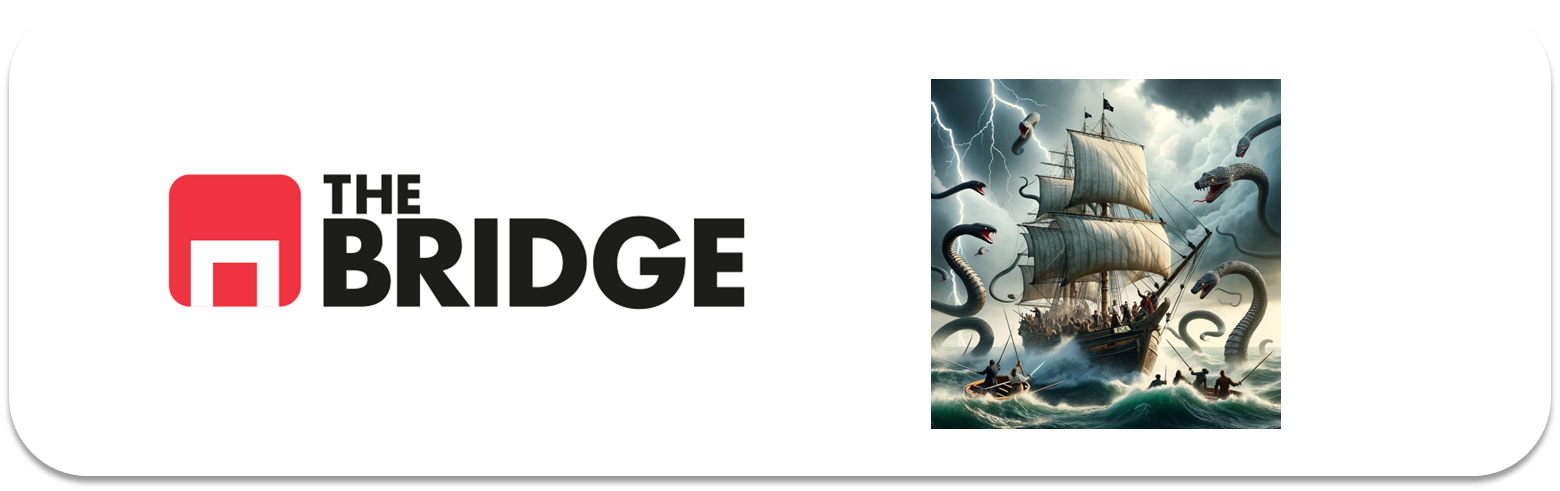

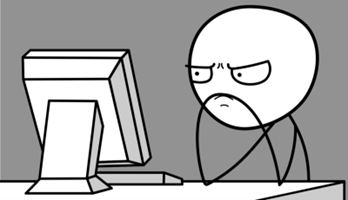

Para ejercitarte y afianzar lo aprendido sobre **Seleccion de Features**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

## Feature selection: Breast Cancer Winsconsin

El objetivo de este grupo de ejercicio es dar a entender la importancia de la selección de características (features), así como probar distintos métodos de reducción de características (features) y qué influencia puede tener el reducir features en el perfomance de un modelo. Nuestro target para evaluar el perfomance será si estamos ante tumores malignos o benignos.

Vamos a trabajar con el dataset de Breast Cancer Winsconsin, datos tomados a partir de radiografías.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
# Tratamiento de datos
# ==============================================================================
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
import matplotlib.font_manager
from matplotlib import style
style.use('ggplot') or plt.style.use('ggplot')

# Preprocesado y modelado
# ==============================================================================
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import scale

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

### Ejercicio 1:

Carga los datos y haz una primera inspección de los mismos y comenta lo que creas conveniente sobre las features y su relación entre sí (pero sin analizarlas numéricamente)

In [2]:
df = pd.read_csv("./data/breastcancer-winsconsin.csv")

In [3]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

The dataset variables are measurements of the same features. E.g radius, texture, perimeter. Each features, has 3 different measurements - mean, se, worst.
Therefore, as they refer to the same features, there is likely to be a high correlation between the variables. As such it will be necessary to reduce the dimensionality of the dataset.

### Ejercicio 2:

Descarta las características que evidentemente no aportan información.

In [5]:
df = df.drop(columns= ["id", "Unnamed: 32"])


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

### Ejercicio 3: 

Divide en train y test. Analiza el target de forma breve.

In [7]:
target = "diagnosis"

X = df.drop(columns = target, axis = 1).copy()
y = df[target].copy()

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42, stratify = y)

In [9]:
y.value_counts(normalize=True)*100

diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64

In [10]:
import bootcampviztools as bt

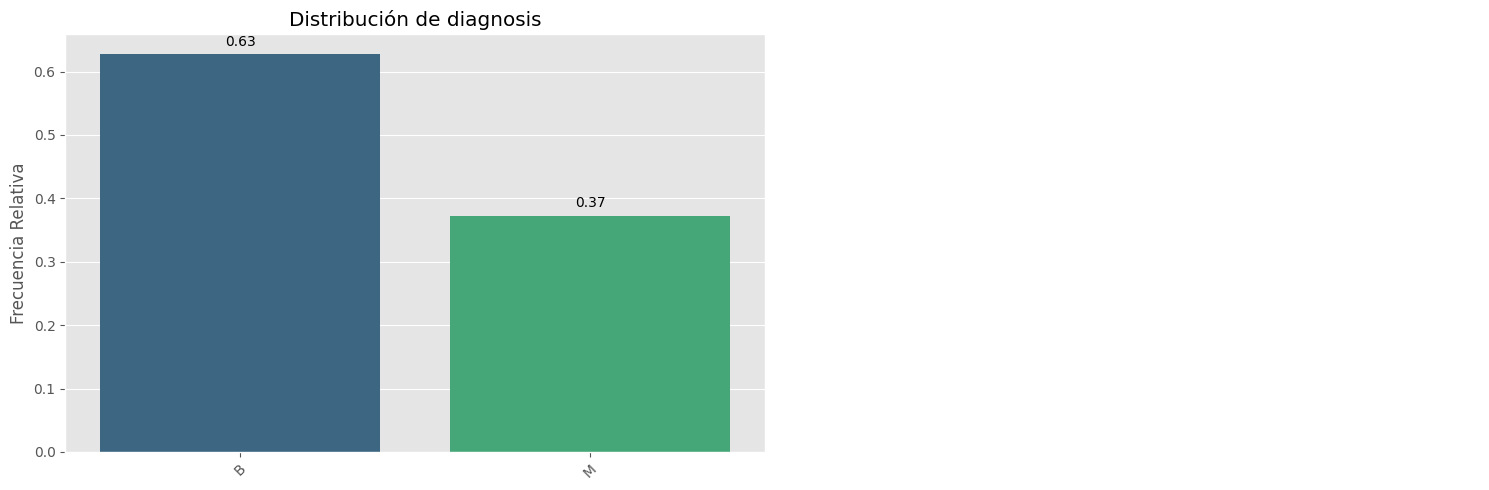

In [11]:
bt.pinta_distribucion_categoricas(df, [target], relativa=True, mostrar_valores=True)

### Ejercicio 4: MiniEDA (I) Análisis Visual

Realiza un análisis visual de las features y haz tu selección de primera "división" (que luego usaremos para comparar con otros métodos de selección).

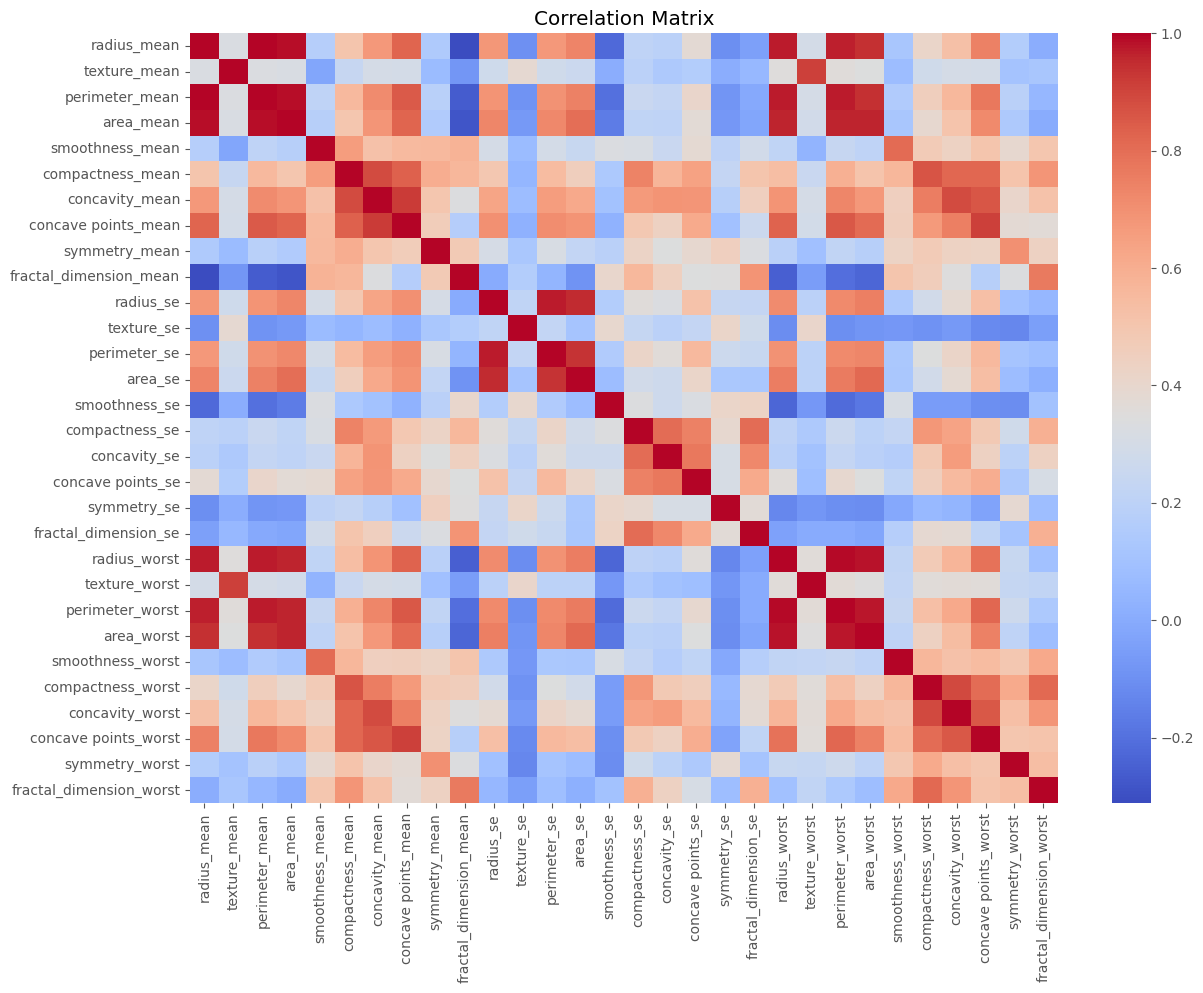

In [12]:
import seaborn as sns

plt.figure(figsize=(14,10))
sns.heatmap(df.drop(target, axis = 1).corr(), cmap= "coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [13]:
features_1 = [col for col in df.columns if "mean" in col]

In [14]:
features_1

['radius_mean',
 'texture_mean',
 'perimeter_mean',
 'area_mean',
 'smoothness_mean',
 'compactness_mean',
 'concavity_mean',
 'concave points_mean',
 'symmetry_mean',
 'fractal_dimension_mean']

### Ejercicio 5

Observa correlaciones entre las features. Utiliza un gráfico apropiado para ello. ¿Crees que sea posible eliminar algunas features para mejorar el modelo? (No hace falta que lo hagas ahora, lo haremos si es necesario en un ejercicio posterior)

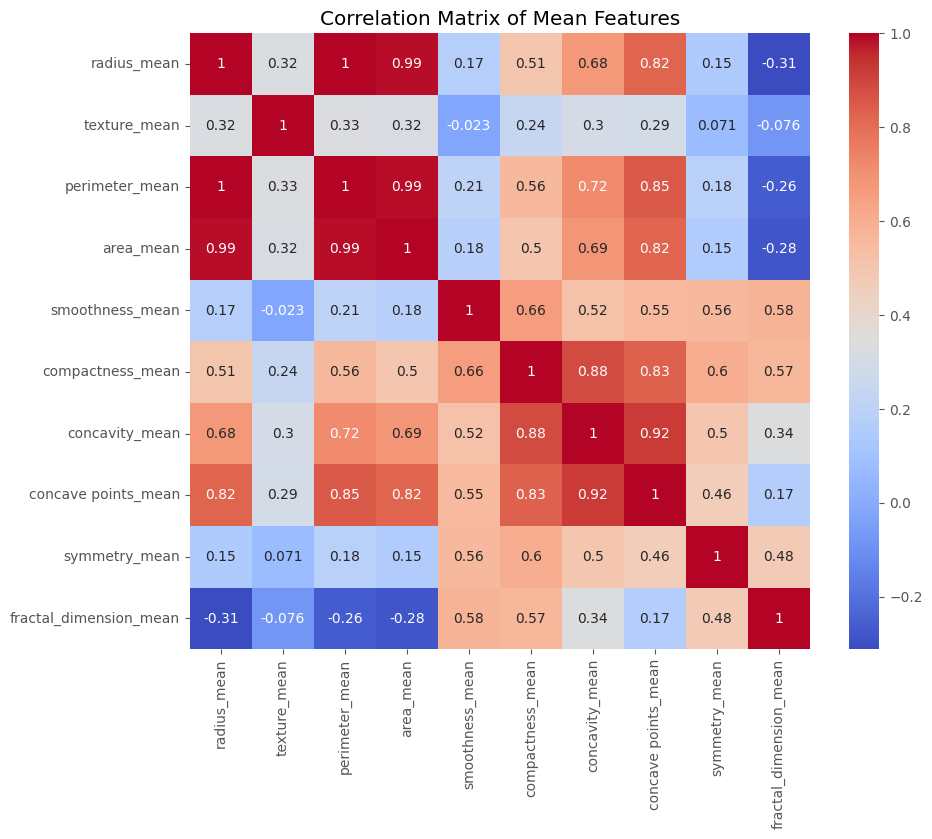

In [15]:
plt.figure(figsize=(10,8))

corr = df[features_1].corr()

sns.heatmap(corr, cmap="coolwarm", annot=True)

plt.title("Correlation Matrix of Mean Features")
plt.show()

### Ejercicio 6:

Entrena (con validación cruzada) un modelo de RandomForestClassifier (con max_depth a 5) con todas las features (ojo incluso las que descartamos en el ejercicio 4) y guarda el perfomance ("balanced_accuracy") en test en una variable. Será nuestro base line de comparación

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

rf = RandomForestClassifier(max_depth=5, random_state=42)

cv_scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring="balanced_accuracy"
)

cv_scores.mean()

np.float64(0.9506707946336428)

In [17]:
from sklearn.metrics import balanced_accuracy_score

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

baseline_balanced_accuracy = balanced_accuracy_score(y_test, y_pred)

baseline_balanced_accuracy

0.9642857142857143

### Ejercicio 7

Vamos a emplear nuestras features del análisis visual pero descartando variables correladas entre sí (emplea la matriz ya obtenida en el ejercicio 5 o bien cualquier medio que creas conveniente). Descarta features y muestra la matriz de correlación para la selección final (recuerda, parte de la lista creada en el ejercicio 4)

In [18]:
df[features_1].corr()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean
radius_mean,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631
texture_mean,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437
perimeter_mean,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477
area_mean,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110
smoothness_mean,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792
compactness_mean,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369
concavity_mean,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783
concave points_mean,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917
symmetry_mean,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921
fractal_dimension_mean,-0.311631,-0.076437,-0.261477,-0.283110,0.584792,0.565369,0.336783,0.166917,0.479921,1.000000


In [23]:
features_2 = [
    "radius_mean",
    "texture_mean",
    "smoothness_mean",
    "concave points_mean",
    "symmetry_mean",
    "fractal_dimension_mean"
]

X_2 = df[features_2]

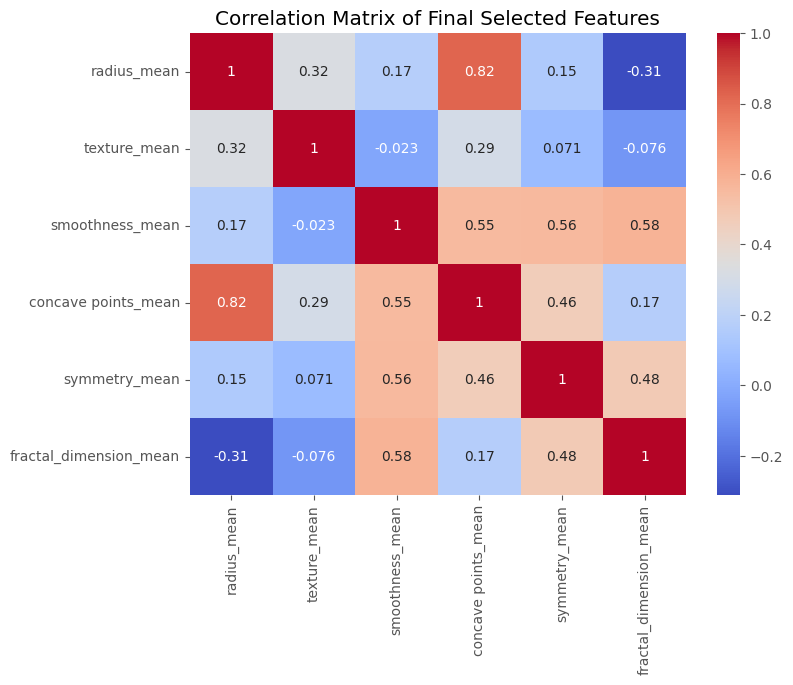

In [22]:
plt.figure(figsize=(8,6))

corr_final = df[features_2].corr()

sns.heatmap(corr_final, cmap="coolwarm", annot=True)

plt.title("Correlation Matrix of Final Selected Features")
plt.show()

### Ejercicio 8

Evalúa tu primer feature reduction. Entrena un modelo y evalúa su perfomance con los features que seleccionaste en el ejercicio anterios (emplea la validación cruzada)

In [24]:
rf = RandomForestClassifier(max_depth=5, random_state=42)

cv_scores_features2 = cross_val_score(
    rf,
    X_2,
    y,
    cv=5,
    scoring="balanced_accuracy"
)

In [25]:
features2_balanced_accuracy = cv_scores_features2.mean()

features2_balanced_accuracy

np.float64(0.9220762559855256)

In [26]:
print("Baseline:", baseline_balanced_accuracy)
print("Feature reduction:", features2_balanced_accuracy)


Baseline: 0.9642857142857143
Feature reduction: 0.9220762559855256


### Ejercicio 9

Prueba ahora a hacer una feature selection utilizando ANOVA. Compara la validación cruzada con la del modelo baseline y con la del modelo anterior. (Pista: SelectKbest)

In [27]:
from sklearn.feature_selection import SelectKBest, f_classif

In [28]:
selector = SelectKBest(score_func=f_classif, k=6)

X_anova = selector.fit_transform(X, y)

In [29]:
selected_features_anova = X.columns[selector.get_support()]

selected_features_anova

Index(['perimeter_mean', 'concave points_mean', 'radius_worst',
       'perimeter_worst', 'area_worst', 'concave points_worst'],
      dtype='object')

In [30]:
rf = RandomForestClassifier(max_depth=5, random_state=42)

anova_cv_scores = cross_val_score(
    rf,
    X_anova,
    y,
    cv=5,
    scoring="balanced_accuracy"
)

In [31]:
anova_balanced_accuracy = anova_cv_scores.mean()

anova_balanced_accuracy

np.float64(0.938111875386687)

In [32]:
print("Baseline (all features):", baseline_balanced_accuracy)
print("Manual feature reduction:", features2_balanced_accuracy)
print("ANOVA feature selection:", anova_balanced_accuracy)

Baseline (all features): 0.9642857142857143
Manual feature reduction: 0.9220762559855256
ANOVA feature selection: 0.938111875386687


### Ejercicio 10

Prueba a hacer ahora una selección de features con RFE (Recursive Feature Elimination), hasta quedarte con 5 features. Evalúa perfomance en "balanced_accuracy" con cross_validation y compara con la baseline.

In [33]:
from sklearn.feature_selection import RFE

rf = RandomForestClassifier(max_depth=5, random_state=42)

rfe = RFE(estimator=rf, n_features_to_select=5)

X_rfe = rfe.fit_transform(X, y)

selected_features_rfe = X.columns[rfe.support_]

selected_features_rfe

Index(['concave points_mean', 'radius_worst', 'perimeter_worst', 'area_worst',
       'concave points_worst'],
      dtype='object')

In [34]:
rfe_cv_scores = cross_val_score(
    rf,
    X_rfe,
    y,
    cv=5,
    scoring="balanced_accuracy"
)

rfe_balanced_accuracy = rfe_cv_scores.mean()

rfe_balanced_accuracy

np.float64(0.9413741492884957)

In [35]:
print("Baseline (all features):", baseline_balanced_accuracy)
print("Manual feature reduction:", features2_balanced_accuracy)
print("ANOVA feature selection:", anova_balanced_accuracy)
print("RFE feature selection:", rfe_balanced_accuracy)

Baseline (all features): 0.9642857142857143
Manual feature reduction: 0.9220762559855256
ANOVA feature selection: 0.938111875386687
RFE feature selection: 0.9413741492884957


### Ejercicio 11

Prueba a eliminar features con el modelo de RandomForestClassifier (emplea SelectFromModel de sklearn). Utiliza esta vez una regresión logística para entrenar con las features escogidas y compara con el baseline. Muestra primero la importancia obtenida con el modelo baseline (que básicamente es el mismo que vamos a usar con SelectFromModel). Prueba primero para features por encima de la mediana y luego para las 5 primeras.

In [36]:
rf = RandomForestClassifier(max_depth=5, random_state=42)

rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

importances

area_worst                 0.152915
concave points_worst       0.134546
radius_worst               0.100371
perimeter_worst            0.087629
concave points_mean        0.083709
perimeter_mean             0.077532
radius_mean                0.059437
concavity_mean             0.051643
area_mean                  0.044947
concavity_worst            0.030722
area_se                    0.022708
radius_se                  0.016456
texture_worst              0.015983
compactness_worst          0.015885
texture_mean               0.014803
smoothness_worst           0.014751
compactness_mean           0.011966
symmetry_worst             0.011351
perimeter_se               0.008026
fractal_dimension_worst    0.006211
concavity_se               0.005093
compactness_se             0.005087
fractal_dimension_se       0.005064
symmetry_mean              0.004212
smoothness_mean            0.004070
fractal_dimension_mean     0.004007
texture_se                 0.003532
symmetry_se                0

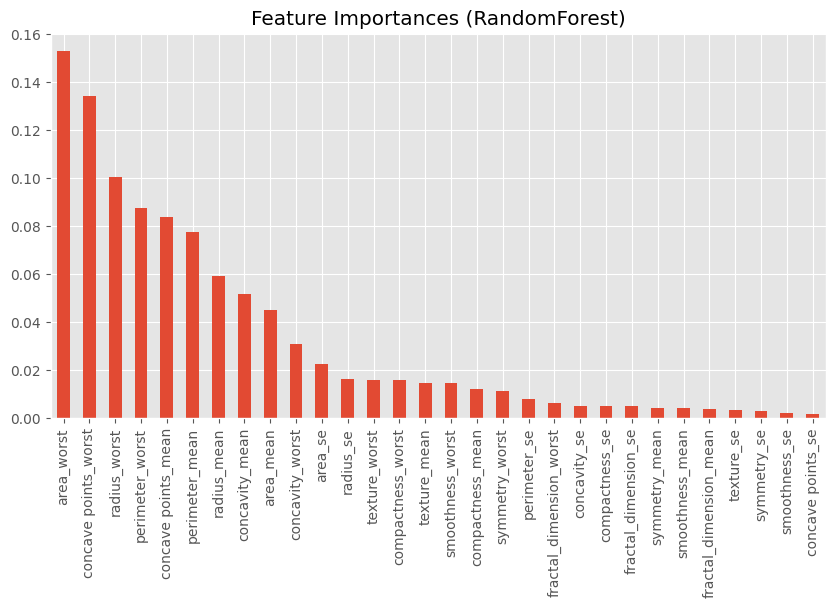

In [37]:
importances.plot(kind="bar", figsize=(10,5))
plt.title("Feature Importances (RandomForest)")
plt.show()

In [38]:
from sklearn.feature_selection import SelectFromModel

selector_median = SelectFromModel(rf, threshold="median")

X_train_median = selector_median.fit_transform(X_train, y_train)
X_test_median = selector_median.transform(X_test)

selected_features_median = X.columns[selector_median.get_support()]

selected_features_median

Index(['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'concavity_mean', 'concave points_mean', 'radius_se', 'area_se',
       'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst'],
      dtype='object')

In [39]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=5000)

cv_scores_median = cross_val_score(
    logreg,
    X_train_median,
    y_train,
    cv=5,
    scoring="balanced_accuracy"
)

median_balanced_accuracy = cv_scores_median.mean()

median_balanced_accuracy

np.float64(0.9436016511867905)

In [40]:
selector_top5 = SelectFromModel(rf, max_features=5, threshold=-float("inf"))

X_train_top5 = selector_top5.fit_transform(X_train, y_train)
X_test_top5 = selector_top5.transform(X_test)

selected_features_top5 = X.columns[selector_top5.get_support()]

selected_features_top5

Index(['concave points_mean', 'radius_worst', 'perimeter_worst', 'area_worst',
       'concave points_worst'],
      dtype='object')

In [41]:
cv_scores_top5 = cross_val_score(
    logreg,
    X_train_top5,
    y_train,
    cv=5,
    scoring="balanced_accuracy"
)

top5_balanced_accuracy = cv_scores_top5.mean()

top5_balanced_accuracy

np.float64(0.9148606811145511)

### Ejercicio EXTRA:

Investiga RFECV y obten el número optimo de features siguiendo esta técnica pero con el "balanced_accuracy" como métrica.

In [42]:
from sklearn.feature_selection import RFECV

from sklearn.model_selection import StratifiedKFold

rfecv = RFECV(
    estimator=rf,
    step=1,
    cv=StratifiedKFold(5),
    scoring="balanced_accuracy"
)

rfecv.fit(X, y)

optimal_features = rfecv.n_features_

optimal_features

np.int64(16)

In [43]:
selected_features_rfecv = X.columns[rfecv.support_]

selected_features_rfecv


Index(['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'concavity_mean', 'concave points_mean', 'area_se', 'radius_worst',
       'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst'],
      dtype='object')

In [44]:
X_rfecv = X[selected_features_rfecv]

rfecv_scores = cross_val_score(
    rf,
    X_rfecv,
    y,
    cv=5,
    scoring="balanced_accuracy"
)

rfecv_balanced_accuracy = rfecv_scores.mean()

rfecv_balanced_accuracy

np.float64(0.9658213492843366)